In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
import os
import sys

sys.path.append(os.path.abspath("../../repos/RiskLabAI.py"))
from src.quantum_hrp import compute_financial_features, fetch_stock_data, average_density_matrix, compute_distance_matrix, quantum_ordering, classical_hrp_ordering, simulate_asset_features_regimes



In [2]:
returns = pd.read_csv("../../data/returns.csv", index_col=0, parse_dates=True)
features = np.load("../../data/features.npy")

# checks básicos
print(returns.shape)   # (T, N)
print(features.shape)  # (N, T, P)


(616, 169)
(169, 616, 6)


In [3]:
R = returns.values
corr = np.corrcoef(R, rowvar=False)

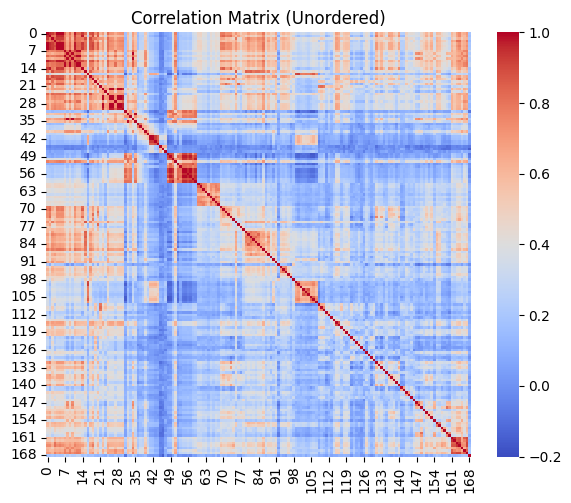

In [4]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True
)

plt.title("Correlation Matrix (Unordered)")
plt.tight_layout()
plt.show()

In [5]:
alpha = 2.0
rho_list = []

for i in range(features.shape[0]):
    rho_i = average_density_matrix(features[i], alpha)
    rho_list.append(rho_i)

D_quantum = compute_distance_matrix(rho_list)

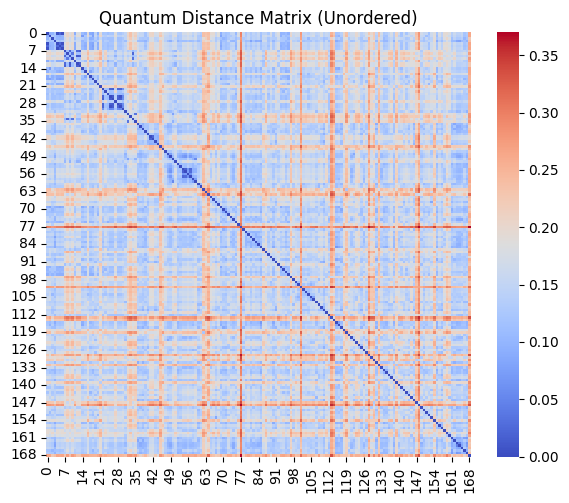

In [6]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    D_quantum,
    cmap="coolwarm",
    square=True,
    cbar=True
)
plt.title("Quantum Distance Matrix (Unordered)")
plt.tight_layout()
plt.show()

In [7]:
# Correlation → distance
dist_classical = np.sqrt(0.5 * (1 - corr))

# Numerical hygiene (CRÍTICO)
dist_classical = 0.5 * (dist_classical + dist_classical.T)
np.fill_diagonal(dist_classical, 0.0)
dist_classical = np.nan_to_num(dist_classical)

# Hierarchical clustering
link_classical = linkage(squareform(dist_classical), method="single")
order_classical = leaves_list(link_classical)


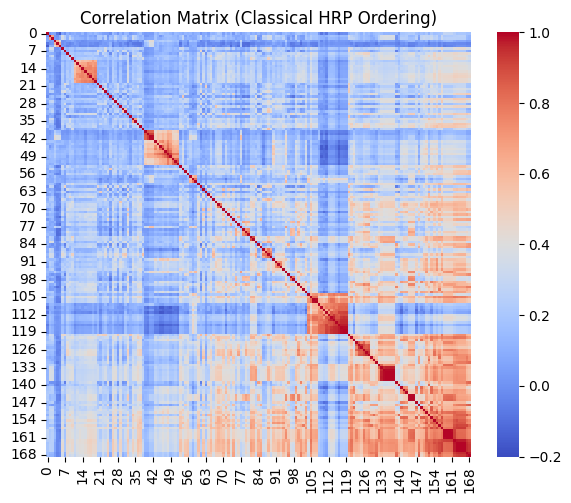

In [8]:
corr_classical = corr[np.ix_(order_classical, order_classical)]

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_classical,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True
)

plt.title("Correlation Matrix (Classical HRP Ordering)")
plt.tight_layout()
plt.show()

In [9]:
link_quantum = linkage(squareform(D_quantum), method="single")
order_quantum = leaves_list(link_quantum)

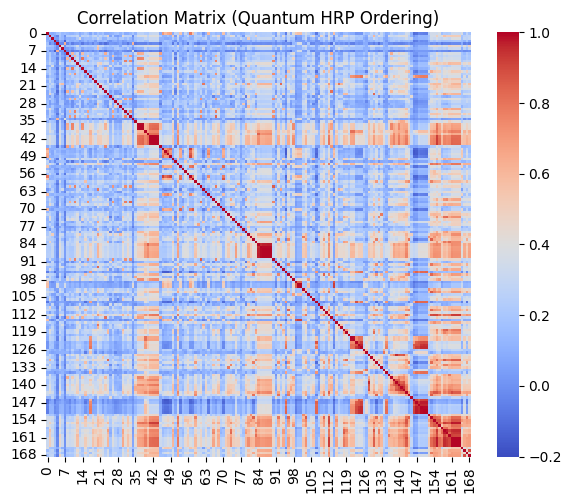

In [10]:
corr_quantum = corr[np.ix_(order_quantum, order_quantum)]

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_quantum,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True
)

plt.title("Correlation Matrix (Quantum HRP Ordering)")
plt.tight_layout()
plt.show()

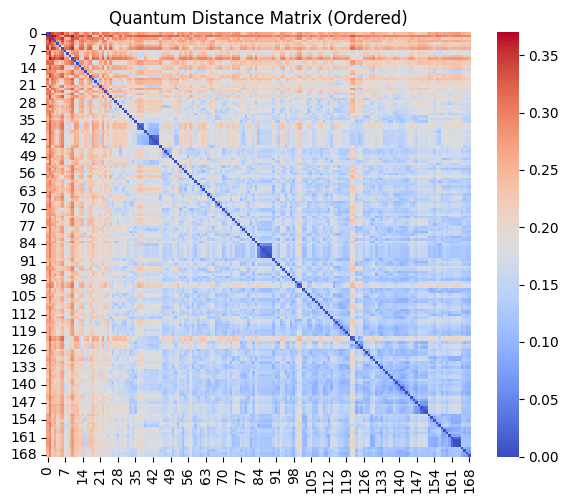

In [11]:
D_quantum_ord = D_quantum[np.ix_(order_quantum, order_quantum)]

plt.figure(figsize=(6, 5))
sns.heatmap(
    D_quantum_ord,
    cmap="coolwarm",
    square=True,
    cbar=True
)
plt.title("Quantum Distance Matrix (Ordered)")
plt.tight_layout()
plt.show()

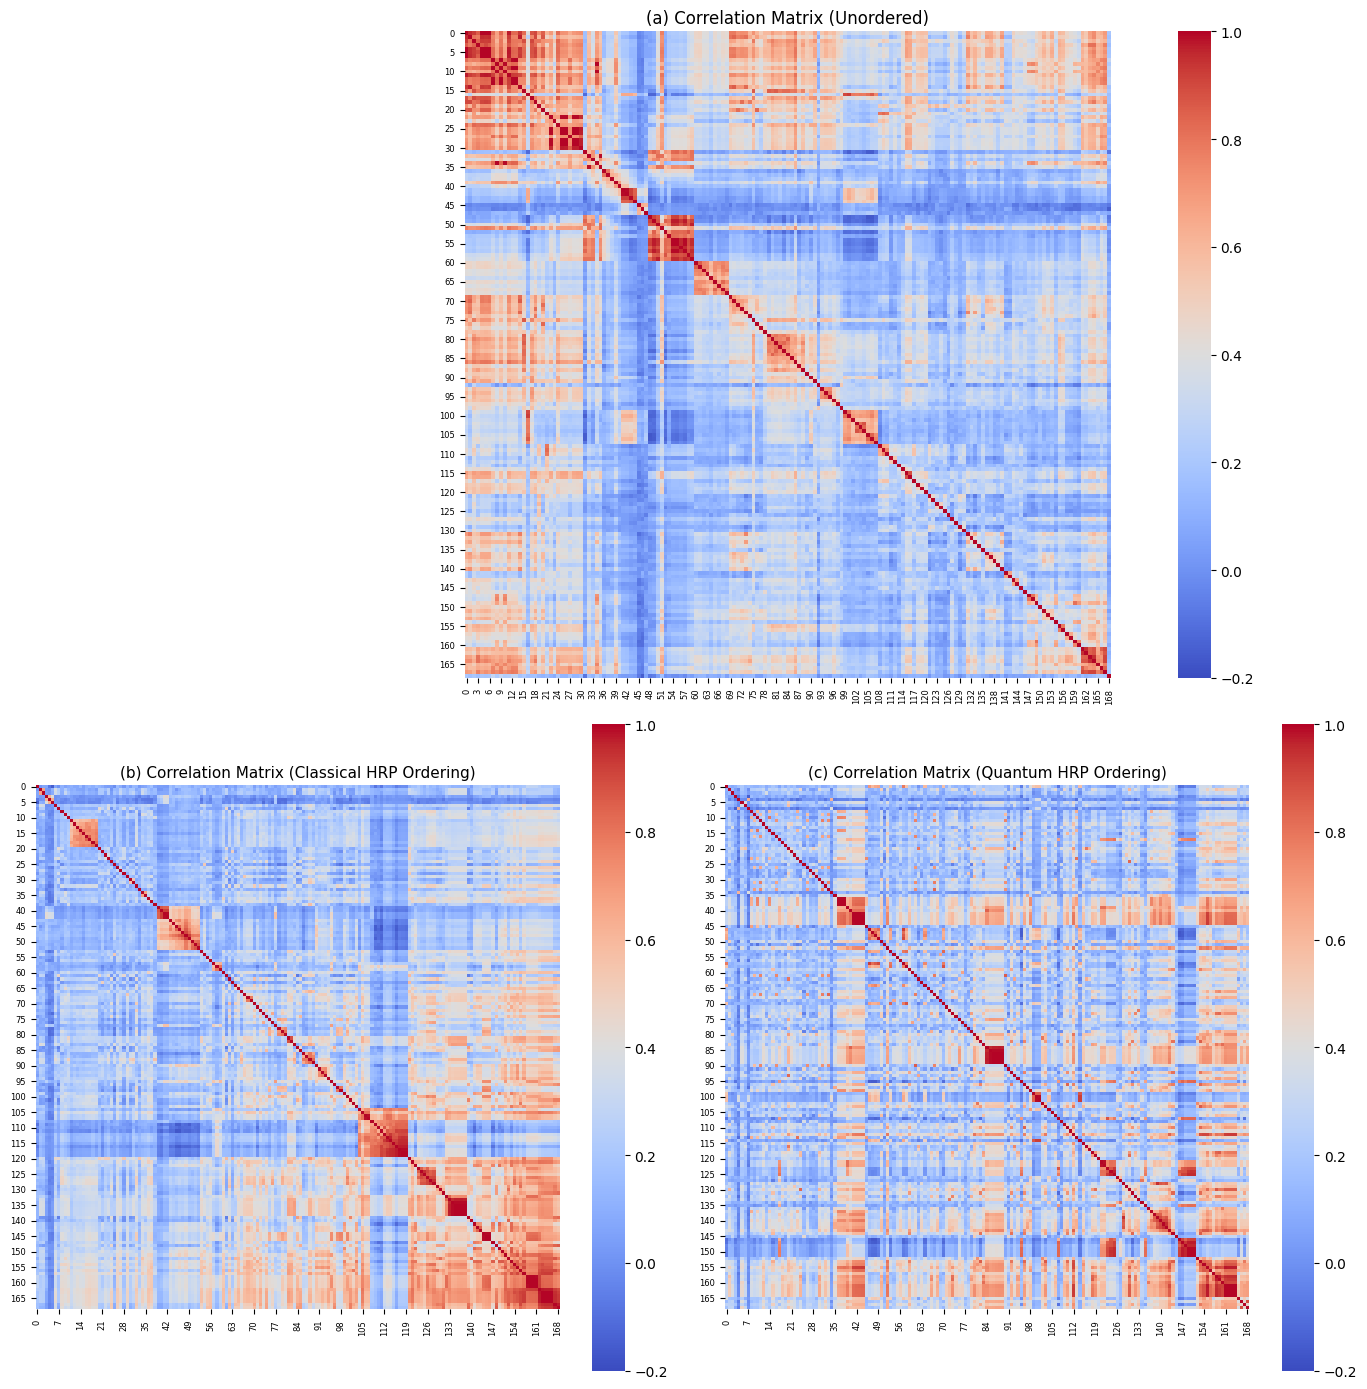

In [13]:
fig = plt.figure(figsize=(14, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# ---------- (a) Unordered ----------
ax0 = fig.add_subplot(gs[0, :])
sns.heatmap(
    corr,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax0
)
ax0.set_title("(a) Correlation Matrix (Unordered)", fontsize=12)
ax0.tick_params(labelsize=6)

# ---------- (b) Classical HRP ----------
ax1 = fig.add_subplot(gs[1, 0])
sns.heatmap(
    corr_classical,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax1
)
ax1.set_title("(b) Correlation Matrix (Classical HRP Ordering)", fontsize=11)
ax1.tick_params(labelsize=6)

# ---------- (c) Quantum HRP ----------
ax2 = fig.add_subplot(gs[1, 1])
sns.heatmap(
    corr_quantum,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax2
)
ax2.set_title("(c) Correlation Matrix (Quantum HRP Ordering)", fontsize=11)
ax2.tick_params(labelsize=6)

plt.tight_layout()
plt.show()

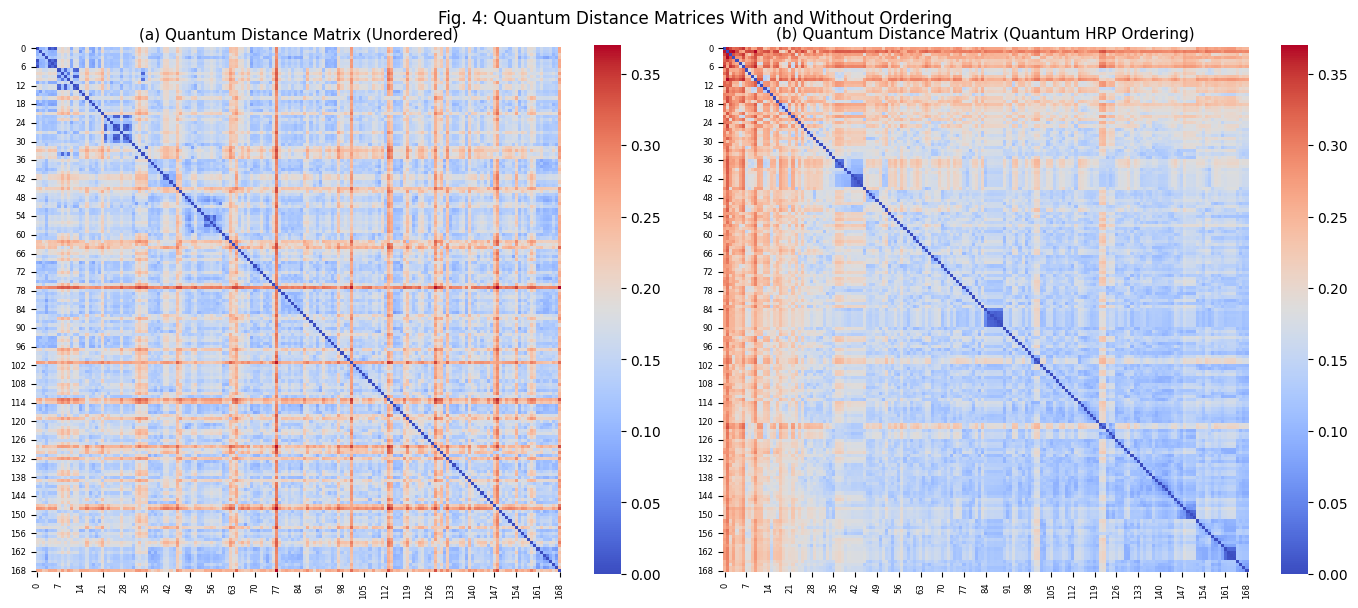

In [17]:
# Reordered quantum distance matrix
D_quantum_ordered = D_quantum[np.ix_(order_quantum, order_quantum)]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------- (a) Unordered ----------
sns.heatmap(
    D_quantum,
    cmap="coolwarm",
    square=True,
    cbar=True,
    ax=axes[0]
)
axes[0].set_title("(a) Quantum Distance Matrix (Unordered)", fontsize=11)
axes[0].tick_params(labelsize=6)

# ---------- (b) Ordered ----------
sns.heatmap(
    D_quantum_ordered,
    cmap="coolwarm",
    square=True,
    cbar=True,
    ax=axes[1]
)
axes[1].set_title("(b) Quantum Distance Matrix (Quantum HRP Ordering)", fontsize=11)
axes[1].tick_params(labelsize=6)

plt.suptitle(
    "Fig. 4: Quantum Distance Matrices With and Without Ordering",
    fontsize=12,
    y=0.98
)

plt.tight_layout()
plt.show()